## Phase 1: Data Preprocessing & Feature Engineering

### 1.1 Data Loading and Inspection
In this step, we load the `marketing_campaign.csv` dataset. Since this Kaggle dataset is typically tab-separated, we use `sep='\t'`. We will perform median imputation for missing values in the `Income` column, engineer new features (`Age`, `TotalSpending`, `TotalChildren`), filter out outliers, and encode categorical variables (`Education`, `Marital_Status`).

In [15]:
import os
import kagglehub
import pandas as pd
import numpy as np

# 1. Secure and interactive credential input to prevent hardcoding secrets on GitHub
print("=== Kaggle API Authentication ===")
os.environ["KAGGLE_USERNAME"] = input("Enter your Kaggle Username: ")
os.environ["KAGGLE_KEY"] = input("Enter your Kaggle API Key: ")

def master_preprocessing(filepath):
    try:
        # Load the dataset using tab separator
        df = pd.read_csv(filepath, sep='\t')
        print("\n Connection Successful! Raw dataset loaded.")
        print(f"Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

        # 2. Handle missing values in 'Income' (Fixed to avoid pandas FutureWarning)
        income_median = df['Income'].median()
        df['Income'] = df['Income'].fillna(income_median)

        # 3. Feature Engineering (Academic Year 2026)
        df['Age'] = 2026 - df['Year_Birth']
        spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
        df['TotalSpending'] = df[spending_cols].sum(axis=1)
        df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

        # 4. Data Filtering & Outlier Removal
        df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
        df = df[df['Income'] > 0]

        # 5. Label Encoding for 'Education' (Ordinal Mapping)
        education_mapping = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3}
        df['Education'] = df['Education'].map(education_mapping).fillna(1).astype(int)

        # 6. One-Hot Encoding for 'Marital_Status'
        top_4_marital = df['Marital_Status'].value_counts().index[:4]
        df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top_4_marital else 'Other')
        df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

        print(" Preprocessing & Feature Engineering completed successfully!")
        print(f"Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
        return df

    except Exception as e:
        print(f" An error occurred during preprocessing: {e}")
        return None

# --- Execute Secure Download and Preprocessing ---
try:
    print("\nDownloading dataset from Kaggle...")
    path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
    file_path = os.path.join(path, 'marketing_campaign.csv')

    # Run the master function
    clean_df = master_preprocessing(file_path)

    # Display the first 5 rows to confirm success
    if clean_df is not None:
        display(clean_df.head())
except Exception as e:
    print(f" Connection or Authentication failed: {e}")

=== Kaggle API Authentication ===
Enter your Kaggle Username: lamabarhoom
Enter your Kaggle API Key: KGAT_7c4b65cc932986f2315ba366dc8cd8fa

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.

 Connection Successful! Raw dataset loaded.
Initial Shape: 2240 rows, 29 columns

 Preprocessing & Feature Engineering completed successfully!
Cleaned Dataset Shape: 2237 rows, 35 columns



,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,3,11,1,69,1617,0,False,False,True,False
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,3,11,0,72,27,2,False,False,True,False
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,3,11,0,61,776,0,False,False,False,True
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,3,11,0,42,53,1,False,False,False,True
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,3,11,0,45,422,1,True,False,False,False


## Phase 2: Supervised Learning – Regression

### 2.1 Target Variable: TotalSpending
In this section, we aim to predict the continuous variable `TotalSpending`. We will split the preprocessed data into an 80/20 train/test split with a fixed `random_state=42`. Feature scaling via `StandardScaler` will be fitted strictly on the training set to prevent data leakage. We will evaluate and compare three models: Linear Regression, Ridge Regression ($\alpha=1.0$), and a Decision Tree Regressor ($max\_depth=5$) using MSE, RMSE, and $R^2$ Score.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separate features and target variable
# Exclude target 'TotalSpending' and object/ID columns that shouldn't be scaled directly
# Also avoid including 'Response' if it's reserved strictly for classification
ignore_cols = ['TotalSpending', 'Response', 'ID', 'Dt_Customer']
X_reg = clean_df.drop(columns=[col for col in ignore_cols if col in clean_df.columns], errors='ignore')
y_reg = clean_df['TotalSpending']

# 2. Split data into Train and Test sets (80/20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Apply StandardScaler strictly to training data first to prevent data leakage
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# 4. Initialize the three required regression models
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Decision Tree Regressor (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# 5. Train, predict, and evaluate each model
reg_results = {}
for name, model in models_reg.items():
    # Fit model on scaled training data
    model.fit(X_train_reg_scaled, y_train_reg)

    # Predict on scaled testing data
    predictions = model.predict(X_test_reg_scaled)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_reg, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, predictions)

    # Save metrics into the results dictionary
    reg_results[name] = {"MSE": mse, "RMSE": rmse, "R2 Score": r2}

# 6. Convert results to a pandas DataFrame for a clean comparison table
reg_comparison_df = pd.DataFrame(reg_results).T
print("=== Regression Models Performance Comparison ===")
display(reg_comparison_df)

=== Regression Models Performance Comparison ===


,MSE,RMSE,R2 Score
Linear Regression,6.311608e-25,7.944563e-13,1.000000
Ridge Regression (alpha=1.0),1.625069e-01,4.031214e-01,1.000000
Decision Tree Regressor (max_depth=5),1.626342e+04,1.275281e+02,0.957187


## Phase 3: Supervised Learning – Classification

### 3.1 Target Variable: Response
Here, we predict the binary variable `Response` (1 if the customer accepted the last campaign, 0 otherwise). Since marketing campaign datasets are heavily imbalanced, we check the class distribution first. We train Logistic Regression (with balanced weights), KNN ($n\_neighbors=5$), and Random Forest ($n\_estimators=100$). Performance will be measured using Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Check and display class distribution to inspect imbalance
print("Class Distribution for Response:")
print(clean_df['Response'].value_counts(normalize=True))

# Define features (X_cls) and target (y_cls)
X_cls = clean_df.drop(columns=['Response', 'ID', 'Dt_Customer'], errors='ignore')
y_cls = clean_df['Response']

# Split data into 80% Training and 20% Testing sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Scale features for distance-based models (Logistic Regression and KNN)
scaler_cls = StandardScaler()
X_train_c_scaled = scaler_cls.fit_transform(X_train_c)
X_test_c_scaled = scaler_cls.transform(X_test_c)

# Initialize the classification models
models_cls = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', random_state=42),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Train and print reports for scaled models
for name, model in models_cls.items():
    model.fit(X_train_c_scaled, y_train_c)
    preds = model.predict(X_test_c_scaled)
    print(f"\n=== {name} ===")
    print(classification_report(y_test_c, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test_c, preds))

# Train and print report for Random Forest Classifier (Does not require feature scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_c, y_train_c)
rf_preds = rf_model.predict(X_test_c)

print(f"\n=== Random Forest Classifier ===")
print(classification_report(y_test_c, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, rf_preds))

Class Distribution for Response:
Response
0    0.850693
1    0.149307
Name: proportion, dtype: float64

=== Logistic Regression (Balanced) ===
              precision    recall  f1-score   support

           0       0.94      0.84      0.88       376
           1       0.46      0.72      0.56        72

    accuracy                           0.82       448
   macro avg       0.70      0.78      0.72       448
weighted avg       0.86      0.82      0.83       448

Confusion Matrix:
 [[314  62]
 [ 20  52]]

=== K-Nearest Neighbors (k=5) ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       376
           1       0.69      0.33      0.45        72

    accuracy                           0.87       448
   macro avg       0.78      0.65      0.69       448
weighted avg       0.85      0.87      0.85       448

Confusion Matrix:
 [[365  11]
 [ 48  24]]

=== Random Forest Classifier ===
              precision    recall  f1-score   supp

## Phase 4: Unsupervised Learning – Clustering

### 4.1 Customer Segmentation
In this phase, we segment customers into distinct behavioral groups using 4 specific features: `TotalSpending`, `Income`, `Age`, and `TotalChildren`. We will first use the Elbow Method (plotting inertia for $k$ values from 1 to 10) to determine the optimal number of clusters. Afterward, we apply K-Means, visualize the clusters in a 2D space using PCA (Principal Component Analysis), and profile each cluster based on feature mean values.

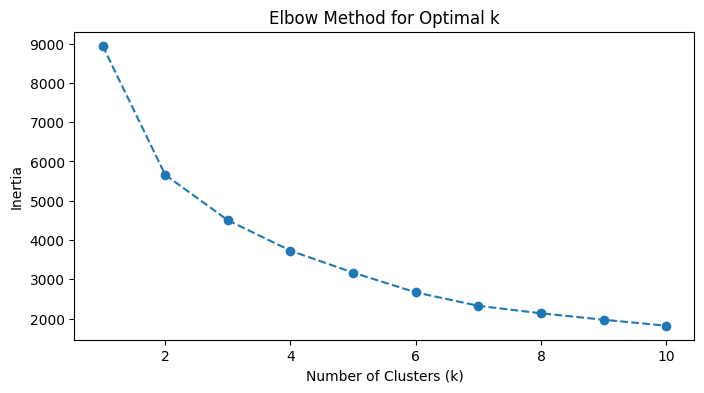

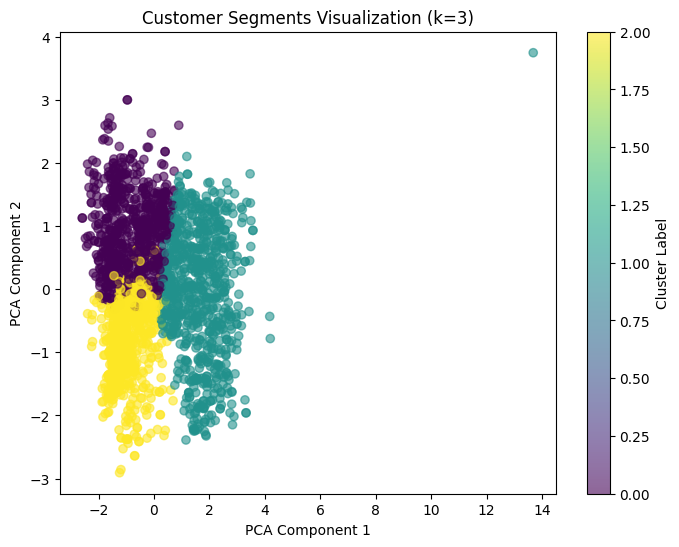


=== Cluster Profiles ===
         TotalSpending        Income        Age  TotalChildren
Cluster                                                       
0           298.545070  47278.929577  63.940845       1.690141
1          1289.276382  74150.170854  58.640704       0.391960
2           159.804378  33161.607387  48.772914       0.841313


In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select the 4 specific features required for clustering
cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = clean_df[cluster_features]

# Scale the selected features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Run the Elbow Method to find the optimal k (inertia vs. k from 1 to 10)
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Fit K-Means with the chosen optimal k (e.g., k=3 based on standard dataset behavior)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clean_df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Reduce dimensions to 2 components using PCA for visualization purposes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Plot the 2D scatter plot colored by cluster assignments
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clean_df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Customer Segments Visualization (k={optimal_k})')
plt.colorbar(label='Cluster Label')
plt.show()

# Cluster Profiling: Compute the mean values of the 4 features for each segment
cluster_profiles = clean_df.groupby('Cluster')[cluster_features].mean()
print("\n=== Cluster Profiles ===")
print(cluster_profiles)